In [32]:
library(ggplot2)
library(org.Hs.eg.db)
library(clusterProfiler)
library(stringr)
library(purrr)
#library(Seurat)

Warning message:
“package ‘ggplot2’ was built under R version 4.0.5”


In [10]:
goanalysis<-function(genes,title){
  print(length(genes))
  gene_up=as.character(na.omit(AnnotationDbi::select(org.Hs.eg.db,
                                                     keys = genes,
                                                     columns = 'ENTREZID',
                                                     keytype = 'SYMBOL')[,2]))
  ## GO
  go.up <- enrichGO(gene = gene_up,
                  OrgDb = org.Hs.eg.db,
                  ont = "BP" ,
                  pAdjustMethod = "BH",
                  pvalueCutoff = 0.99,
                  qvalueCutoff = 0.99,
                  readabl = TRUE)
  dotplot(go.up,orderBy = "x",title=paste0(title,"(",length(genes),")"))+ 
    scale_y_discrete(labels=function(x) str_wrap(x, width=40))+theme_bw() +  
    theme(panel.grid=element_blank(),
        axis.title = element_text(size = 16),
        axis.text = element_text(size = 11))
}

In [12]:
deg_b0<-read.csv('data/PBMC_raw_count_b0_deg.csv',row.names = 1)
deg_b1<-read.csv('data/PBMC_raw_count_b1_deg.csv',row.names = 1)
deg_b1n<-read.csv('data/PBMC_normlized_data_1e3_b1_deg.csv',row.names = 1)

In [13]:
genes<-lapply(lapply(deg_b0,function(x)x[1:500]),function(x){as.data.frame(AnnotationDbi::select(org.Hs.eg.db,
                                                     keys = x,
                                                     columns = 'ENTREZID',
                                                     keytype = 'ENSEMBL'))[,2]})

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns



In [14]:
ground.go <- genes %>% map( ~ {
  res <-
    enrichGO(
      gene = .x,
      ont = 'BP',
      OrgDb = org.Hs.eg.db,
      pvalueCutoff = 0.05,
      pAdjustMethod = 'BH'
    )
  return(res)
})

In [15]:
ground.go<-do.call(rbind,lapply(names(ground.go),function(i){x<-as.data.frame(ground.go[[i]]);x$celltype<- i;return(x)}))

In [16]:
write.csv(ground.go,'data/PBMC_groundgo.csv')

In [17]:
genes<-lapply(lapply(deg_b1,function(x)x[1:500]),function(x){as.data.frame(AnnotationDbi::select(org.Hs.eg.db,
                                                     keys = x,
                                                     columns = 'ENTREZID',
                                                     keytype = 'ENSEMBL'))[,2]})

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns



In [18]:
after.go <- genes %>% map( ~ {
  res <-
    enrichGO(
      gene = .x,
      ont = 'BP',
      OrgDb = org.Hs.eg.db,
      pvalueCutoff = 0.05,
      pAdjustMethod = 'BH'
    )
  return(res)
})

In [19]:
after.go<-do.call(rbind,lapply(names(after.go),function(i){x<-as.data.frame(after.go[[i]]);x$celltype<- i;return(x)}))

In [20]:
write.csv(after.go,'data/PBMC_aftergo.csv')

In [21]:
genes<-lapply(lapply(deg_b1n,function(x)x[1:500]),function(x){as.data.frame(AnnotationDbi::select(org.Hs.eg.db,
                                                     keys = x,
                                                     columns = 'ENTREZID',
                                                     keytype = 'ENSEMBL'))[,2]})

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns



In [22]:
before.go <- genes %>% map( ~ {
  res <-
    enrichGO(
      gene = .x,
      ont = 'BP',
      OrgDb = org.Hs.eg.db,
      pvalueCutoff = 0.05,
      pAdjustMethod = 'BH'
    )
  return(res)
})

In [23]:
before.go<-do.call(rbind,lapply(names(before.go),function(i){x<-as.data.frame(before.go[[i]]);x$celltype<- i;return(x)}))

In [24]:
write.csv(before.go,'data/PBMC_beforego.csv')

In [25]:
genes<-lapply(list(deg_b0$`HSPC`[1:1000],deg_b1$`HSPC`[1:1000],deg_b1n$`HSPC`[1:1000]),function(x){as.data.frame(AnnotationDbi::select(org.Hs.eg.db,
                                                     keys = x,
                                                     columns = 'ENTREZID',
                                                     keytype = 'ENSEMBL'))[,2]})

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns



### BP

In [26]:
go.ls <- genes %>% map( ~ {
  res <-
    enrichGO(
      gene = .x,
      ont = 'BP',
      OrgDb = org.Hs.eg.db,
      pvalueCutoff = 0.05,
      pAdjustMethod = 'BH'
    )
  return(res)
})

In [27]:
go_terms=intersect(intersect(go.ls[[1]]$Description,(go.ls[[2]]$Description)),c("hematopoietic stem cell differentiation",
"hematopoietic stem cell proliferation",
"hematopoietic progenitor cell differentiation",
"regulation of hematopoietic stem cell differentiation",
"regulation of hematopoiesis",
"myeloid cell homeostasis",
"positive regulation of cell cycle",
"regulation of stem cell differentiation",
"positive regulation of hematopoietic stem cell proliferation",
"negative regulation of stem cell differentiation",
"positive regulation of hematopoietic progenitor cell differentiation",
"regulation of cell cycle phase transition",
"regulation of cell cycle G2/M phase transition",
"cell cycle G2/M phase transition",
"mitotic cell cycle checkpoint",
"mitotic DNA integrity checkpoint",
"mitotic DNA damage checkpoint",
"response to oxidative stress",
"cellular response to oxidative stress",
"response to reactive oxygen species",
"regulation of response to oxidative stress",
"regulation of intrinsic apoptotic signaling pathway",
"positive regulation of intrinsic apoptotic signaling pathway",
"negative regulation of intrinsic apoptotic signaling pathway",
"regulation of proteolysis involved in cellular protein catabolic process"))

In [28]:
length(c("hematopoietic stem cell differentiation",
"hematopoietic stem cell proliferation",
"hematopoietic progenitor cell differentiation",
"regulation of hematopoietic stem cell differentiation",
"regulation of hematopoiesis",
"myeloid cell homeostasis",
"positive regulation of cell cycle",
"regulation of stem cell differentiation",
"positive regulation of hematopoietic stem cell proliferation",
"negative regulation of stem cell differentiation",
"positive regulation of hematopoietic progenitor cell differentiation",
"regulation of cell cycle phase transition",
"regulation of cell cycle G2/M phase transition",
"cell cycle G2/M phase transition",
"mitotic cell cycle checkpoint",
"mitotic DNA integrity checkpoint",
"mitotic DNA damage checkpoint",
"response to oxidative stress",
"cellular response to oxidative stress",
"response to reactive oxygen species",
"regulation of response to oxidative stress",
"regulation of intrinsic apoptotic signaling pathway",
"positive regulation of intrinsic apoptotic signaling pathway",
"negative regulation of intrinsic apoptotic signaling pathway",
"regulation of proteolysis involved in cellular protein catabolic process"))

[1] 25

In [29]:
go_terms = c("hematopoietic stem cell differentiation",
"hematopoietic stem cell proliferation",
"hematopoietic progenitor cell differentiation",
"regulation of hematopoietic stem cell differentiation",
"regulation of hematopoiesis",
"myeloid cell homeostasis",
"positive regulation of cell cycle",
"regulation of stem cell differentiation",
"positive regulation of hematopoietic stem cell proliferation",
"negative regulation of stem cell differentiation",
"positive regulation of hematopoietic progenitor cell differentiation",
"regulation of cell cycle phase transition",
"regulation of cell cycle G2/M phase transition",
"cell cycle G2/M phase transition",
"mitotic cell cycle checkpoint",
"mitotic DNA integrity checkpoint",
"mitotic DNA damage checkpoint",
"response to oxidative stress",
"cellular response to oxidative stress",
"response to reactive oxygen species",
"regulation of response to oxidative stress",
"regulation of intrinsic apoptotic signaling pathway",
"positive regulation of intrinsic apoptotic signaling pathway",
"negative regulation of intrinsic apoptotic signaling pathway",
"regulation of proteolysis involved in cellular protein catabolic process")

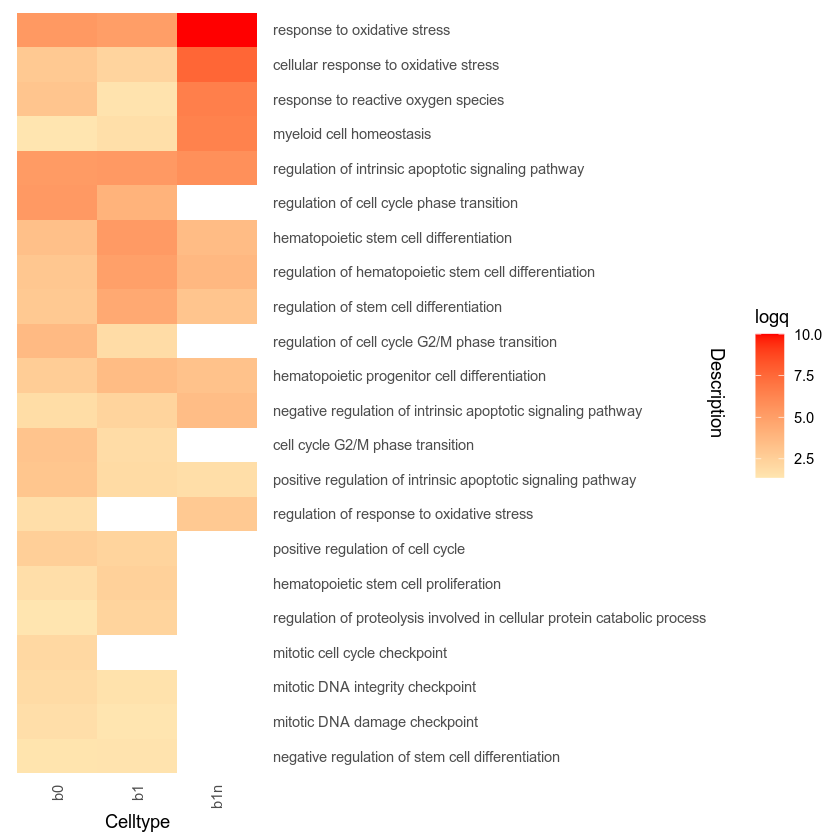

In [33]:
tmp<-do.call(rbind,lapply(go.ls,function(x)as.data.frame(x)))
tmp$Celltype<-rep(c("b0","b1","b1n"),sapply(go.ls,function(x)nrow(x)))
tmp <-tmp[order(tmp$qvalue),]
tmp1<-tmp[tmp$Description %in% go_terms,]
tmp1$logq<- -log10(tmp1$qvalue)
tmp1$Description<-factor(tmp1$Description, levels = rev(unique(tmp$Description)))
tmp1$Celltype<-factor(tmp1$Celltype,levels = c("b0","b1","b1n"))
ggplot(tmp1, aes(Celltype, Description, fill= logq))+geom_tile()+scale_y_discrete(position = "right")+ theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))+
  scale_fill_gradient2(low = "#075AFF",
   mid = "#FFFFCC",
   high = "#FF0000")+
  theme(axis.ticks.x = element_blank(), axis.ticks.y = element_blank())+
  theme(#axis.line = element_line(colour = "black"),
    panel.grid=element_blank(),
    panel.border = element_blank(),
    panel.background = element_blank()) 

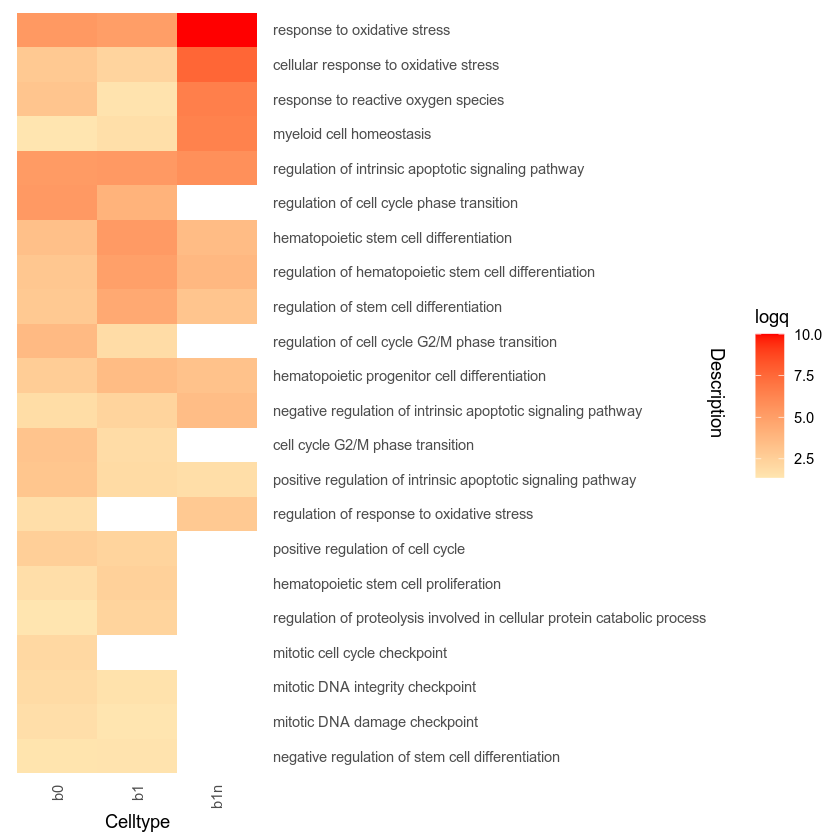

In [34]:
tmp<-do.call(rbind,lapply(go.ls,function(x)as.data.frame(x)))
tmp$Celltype<-rep(c("b0","b1","b1n"),sapply(go.ls,function(x)nrow(x)))
tmp <-tmp[order(tmp$qvalue),]
tmp1<-tmp[tmp$Description %in% go_terms,]
tmp1$logq<- -log10(tmp1$qvalue)
tmp1$Description<-factor(tmp1$Description, levels = rev(unique(tmp$Description)))
tmp1$Celltype<-factor(tmp1$Celltype,levels = c("b0","b1","b1n"))
ggplot(tmp1, aes(Celltype, Description, fill= logq))+geom_tile()+scale_y_discrete(position = "right")+ theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))+
  scale_fill_gradient2(low = "#075AFF",
   mid = "#FFFFCC",
   high = "#FF0000")+
  theme(axis.ticks.x = element_blank(), axis.ticks.y = element_blank())+
  theme(#axis.line = element_line(colour = "black"),
    panel.grid=element_blank(),
    panel.border = element_blank(),
    panel.background = element_blank()) 

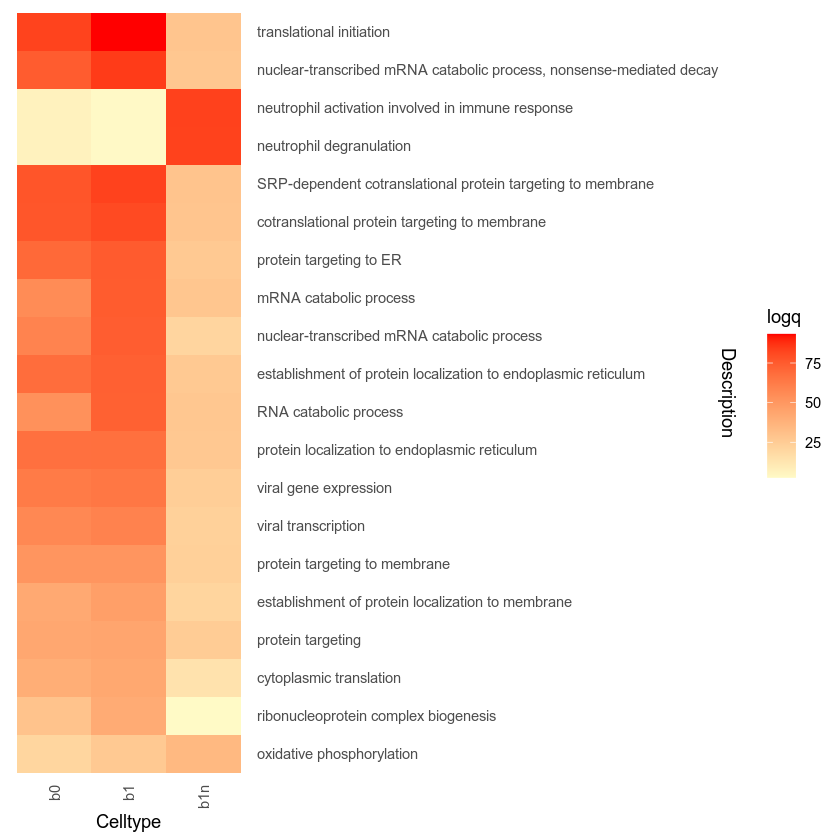

In [35]:
tmp<-do.call(rbind,lapply(go.ls,function(x)as.data.frame(x)))
tmp$Celltype<-rep(c("b0","b1","b1n"),sapply(go.ls,function(x)nrow(x)))
tmp <-tmp[order(tmp$qvalue),]
tmp1<-tmp[tmp$Description %in% unique(tmp$Description)[1:20],]
tmp1$logq<- -log10(tmp1$qvalue)
tmp1$Description<-factor(tmp1$Description, levels = rev(unique(tmp$Description)[1:20]))
tmp1$Celltype<-factor(tmp1$Celltype,levels = c("b0","b1","b1n"))
ggplot(tmp1, aes(Celltype, Description, fill= logq))+geom_tile()+scale_y_discrete(position = "right")+ theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))+
  scale_fill_gradient2(low = "#075AFF",
   mid = "#FFFFCC",
   high = "#FF0000")+
  theme(axis.ticks.x = element_blank(), axis.ticks.y = element_blank())+
  theme(#axis.line = element_line(colour = "black"),
    panel.grid=element_blank(),
    panel.border = element_blank(),
    panel.background = element_blank()) 

In [37]:
write.csv(tmp,'data/PBMC_go_analysis_result.csv')